# TTS Missing Data Analysis
## Notebook 04 — ML for small-N
**Paper**: Missing Data as a Methodological Challenge in Rare Cardiac Disease Registries  
**Dataset**: TAKO_TSUBO_EF.xls — N=57 pazienti, foglio Baseline

> **Istruzioni**: esegui le celle nell'ordine. Dopo la Cella 1 (installazione) riavvia il runtime prima di procedere.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELLA 1: INSTALLAZIONE
# Eseguire UNA VOLTA, poi riavviare il runtime:
# Runtime → Riavvia sessione
# ═══════════════════════════════════════════════════════════════

!pip install -q miceforest xlrd==2.0.1 pingouin shap

print("Installazione completata.")
print("→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 6.9 MB/s eta 0:00:00
Installazione completata.
→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELLA 2: CONFIGURAZIONE PERCORSO DRIVE
# Modifica PROJECT_FOLDER con il nome della tua cartella su MyDrive
# ═══════════════════════════════════════════════════════════════

PROJECT_FOLDER = 'TTS_Research'   # ← modifica qui con TTS_Research

BASE      = f'/content/drive/MyDrive/TTS_Research'
DATA_PATH = f'{BASE}/data/TAKO_TSUBO_EF.xls'
FIG_PATH  = f'{BASE}/outputs/figures/'
TAB_PATH  = f'{BASE}/outputs/tables/'

print(f'BASE      : {BASE}')
print(f'DATA_PATH : {DATA_PATH}')

BASE      : /content/drive/MyDrive/TTS_Research
DATA_PATH : /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELLA 3: SETUP — mount Drive, cartelle, import, seed
# Eseguire dopo il riavvio del runtime.
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os

# Crea cartelle se non esistono
for path in [f'{BASE}/data',
             f'{BASE}/outputs/figures',
             f'{BASE}/outputs/tables',
             f'{BASE}/notebooks']:
    os.makedirs(path, exist_ok=True)

# Verifica percorsi critici
for path in [BASE, DATA_PATH]:
    status = 'OK' if os.path.exists(path) else 'MANCANTE'
    print(f'{status}: {path}')

# Seed globale
import numpy as np, random
SEED = 42
np.random.seed(SEED); random.seed(SEED)

# Import standard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.base import clone
import sklearn, warnings
from sklearn.linear_model import ElasticNetCV
warnings.filterwarnings('ignore')

print(f'pandas:  {pd.__version__}')
print(f'numpy:   {np.__version__}')
print(f'sklearn: {sklearn.__version__}')
print('Setup completato.')

Mounted at /content/drive
OK: /content/drive/MyDrive/TTS_Research
OK: /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls
pandas:  2.2.2
numpy:   2.0.2
sklearn: 1.6.1
Setup completato.


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELLA 4: CARICAMENTO E PULIZIA DATASET
# ═══════════════════════════════════════════════════════════════

df_raw = pd.read_excel(DATA_PATH, engine='xlrd', sheet_name='Baseline')
print(f'Righe raw: {len(df_raw)}')

df = df_raw.copy()

# Verifica integrità
assert len(df) == 57, f'Attesi 57 pazienti, trovati {len(df)}'
assert df['LVEF'].notna().sum() == 57, 'LVEF non completa'

print(f'Dataset pulito: {df.shape[0]} pazienti, {df.shape[1]} variabili')
print(f'LVEF: {df["LVEF"].min():.1f} - {df["LVEF"].max():.1f}%  '
      f'(media {df["LVEF"].mean():.1f} ± {df["LVEF"].std():.1f}%)')
print(f'LVEF < 50: {(df["LVEF"]<50).sum()} pazienti | '
      f'LVEF >= 50: {(df["LVEF"]>=50).sum()} pazienti')

Righe raw: 57
Dataset pulito: 57 pazienti, 168 variabili
LVEF: 26.0 - 76.0%  (media 52.5 ± 10.7%)
LVEF < 50: 21 pazienti | LVEF >= 50: 36 pazienti


In [5]:
# ═══════════════════════════════════════════════════════════════
# SETUP AMBIENTE E CARICAMENTO DATI (NOTEBOOK 04)
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Import necessari per il Benchmark
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Montaggio Google Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Configurazione Percorsi Globali
BASE_PATH = '/content/drive/MyDrive/TTS_Research/'
TAB_PATH  = f'{BASE_PATH}outputs/tables/'
FIG_PATH  = f'{BASE_PATH}outputs/figures/'
DATA_PATH = f'{BASE_PATH}data/TAKO_TSUBO_EF.xls'

# 3. Definizioni Globali
TARGET = 'LVEF'
SEED = 42
np.random.seed(SEED)

print("--- Inizio Caricamento Asset ---")

# 4. Caricamento Output dal Notebook 1 (tab1)
try:
    tab1 = pd.read_csv(f'{TAB_PATH}tabella_01_missingness_summary.csv')
    print("Tabella 1 (Missing Summary) caricata con successo.")
except FileNotFoundError:
    print("Attenzione: Tabella 1 non trovata in Drive. Verrà ricreata se necessario.")

# 5. Caricamento Dataset e Creazione df_extended
try:
    # Carichiamo l'Excel
    df_raw = pd.read_excel(DATA_PATH, sheet_name='Baseline')
    df_work = df_raw.select_dtypes(include=[np.number])

    # Ricreiamo gli Indicatori M (per il Notebook 04)
    feat_cols = [c for c in df_work.columns if c != TARGET]
    miss_ind = df_work[feat_cols].isna().astype(int)
    miss_ind.columns = ['M_' + c for c in feat_cols]

    # Filtro: almeno 5 missing (dal Notebook 03)
    useful_M = [c for c in miss_ind.columns if miss_ind[c].sum() >= 5]
    miss_ind_useful = miss_ind[useful_M]

    # Dataset Finale per il Benchmark
    df_extended = pd.concat([df_work, miss_ind_useful], axis=1)

    print(f"Dataset caricato correttamente.")
    print(f"df_extended pronto: {df_extended.shape[0]} pazienti, {df_extended.shape[1]} variabili.")
    print(f"Indicatori M inclusi: {len(useful_M)}")

except Exception as e:
    print(f"ERRORE : {e}")

print("--- Setup Completato ---")

--- Inizio Caricamento Asset ---
Tabella 1 (Missing Summary) caricata con successo.
Dataset caricato correttamente.
df_extended pronto: 57 pazienti, 297 variabili.
Indicatori M inclusi: 148
--- Setup Completato ---


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5: 5.1 DEFINIZIONE DEI MODELLI PER IL BENCHMARK
# ═══════════════════════════════════════════════════════════════

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Definiamo il dizionario dei modelli
MODELLI = {
    'Ridge':      Ridge(alpha=1.0),

    'Lasso':      Lasso(alpha=0.1, random_state=SEED, max_iter=5000),

    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=SEED, max_iter=5000),

    'SVR':        SVR(kernel='rbf', C=1.0, epsilon=0.1),

    'RF':         RandomForestRegressor(n_estimators=100, max_depth=3,
                                        min_samples_leaf=5, random_state=SEED, n_jobs=-1),

    'XGBoost':    XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8,
                               random_state=SEED, verbosity=0, n_jobs=-1)
}

print(f" {len(MODELLI)} modelli pronti per il benchmark.")
print("Modelli inclusi: " + ", ".join(MODELLI.keys()))

 6 modelli pronti per il benchmark.
Modelli inclusi: Ridge, Lasso, ElasticNet, SVR, RF, XGBoost


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5.2: ESECUZIONE BENCHMARK (LOOCV)
# ═══════════════════════════════════════════════════════════════

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.base import clone
import time

def loocv_benchmark(df_w, target_col, modelli_dict):
    results = {}
    feat = [c for c in df_w.columns if c != target_col]
    N = len(df_w)

    for nome, modello in modelli_dict.items():
        print(f"Valutazione modello: {nome}...", end=" ")
        start_m = time.time()

        y_true = []
        y_pred = []

        # Loop Leave-One-Out (un paziente alla volta come test)
        for i in range(N):
            # Split
            train_idx = [j for j in range(N) if j != i]
            df_train = df_w.iloc[train_idx].reset_index(drop=True)
            df_test  = df_w.iloc[[i]].reset_index(drop=True)

            X_train, y_train = df_train[feat], df_train[target_col]
            X_test, y_test   = df_test[feat], df_test[target_col]

            # 1. Imputazione (KNN)
            imp = KNNImputer(n_neighbors=5)
            X_train_i = imp.fit_transform(X_train)
            X_test_i  = imp.transform(X_test)

            # 2. Scaling
            sc = StandardScaler()
            X_train_s = sc.fit_transform(X_train_i)
            X_test_s  = sc.transform(X_test_i)

            # 3. Fit & Predict
            m = clone(modello)
            m.fit(X_train_s, y_train)
            p = m.predict(X_test_s)[0]

            y_true.append(y_test.values[0])
            y_pred.append(p)

        # Calcolo Metriche
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        durata = time.time() - start_m

        results[nome] = {'MAE': mae, 'R2': r2, 'Preds': y_pred}
        print(f"Fatto! (MAE: {mae:.2f} | Tempo: {durata:.1f}s)")

    return results, y_true

# ESECUZIONE ( df_extended creato nel notebook 3)
risultati_ml, y_reale = loocv_benchmark(df_extended, 'LVEF', MODELLI)

# Trasformiamo in DataFrame per vedere la classifica
tabella_finale = pd.DataFrame({n: {'MAE': r['MAE'], 'R2': r['R2']}
                               for n, r in risultati_ml.items()}).T
tabella_finale = tabella_finale.sort_values(by='MAE')

print("\n" + "═"*40)
print(" CLASSIFICA FINALE DEI MODELLI")
print("═"*40)
print(tabella_finale)

Valutazione modello: Ridge... Fatto! (MAE: 11.15 | Tempo: 20.7s)
Valutazione modello: Lasso... Fatto! (MAE: 9.40 | Tempo: 14.3s)
Valutazione modello: ElasticNet... Fatto! (MAE: 8.62 | Tempo: 9.5s)
Valutazione modello: SVR... Fatto! (MAE: 8.74 | Tempo: 7.9s)
Valutazione modello: RF... Fatto! (MAE: 8.20 | Tempo: 23.0s)
Valutazione modello: XGBoost... Fatto! (MAE: 8.25 | Tempo: 11.6s)

════════════════════════════════════════
 CLASSIFICA FINALE DEI MODELLI
════════════════════════════════════════
                  MAE        R2
RF           8.197798  0.029793
XGBoost      8.252226  0.014958
ElasticNet   8.619546 -0.091079
SVR          8.744924 -0.017869
Lasso        9.401330 -0.327068
Ridge       11.150184 -3.364487


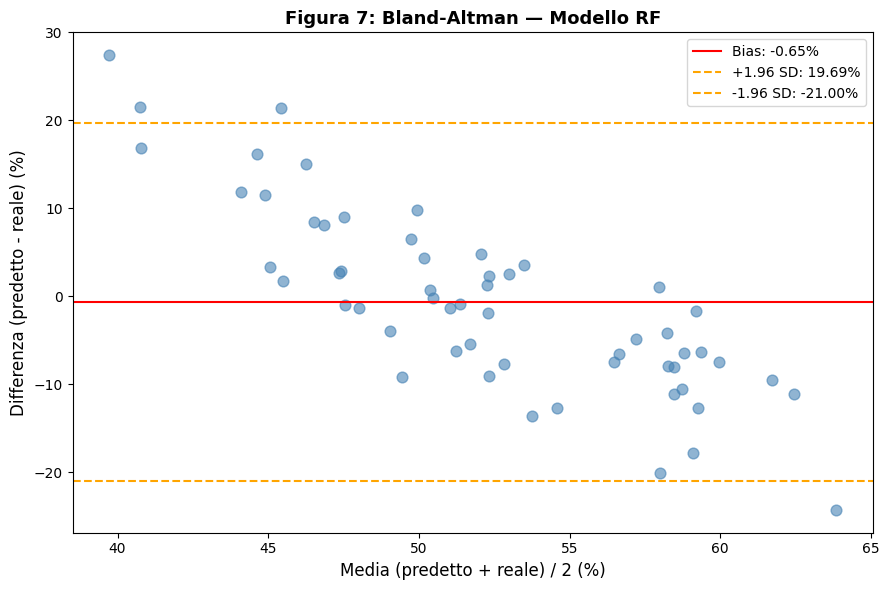

Analisi di Bland-Altman completata per il modello: RF
Bias medio: -0.65% (Se vicino a 0, il modello non ha errori sistematici)


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5.3: BLAND-ALTMAN PLOT PER IL MODELLO MIGLIORE
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

# 1. Identifichiamo il modello con il MAE più basso
best = min(risultati_ml, key=lambda k: risultati_ml[k]['MAE'])
preds_b = np.array(risultati_ml[best]['Preds'])
trues_b = np.array(y_reale)

# 2. Calcolo statistiche per Bland-Altman
means = (preds_b + trues_b) / 2
diffs = preds_b - trues_b
bias = np.mean(diffs)
sd = np.std(diffs)

# 3. Generazione del Grafico
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(means, diffs, alpha=0.6, color='steelblue', s=60)

# Linea del Bias (errore medio)
ax.axhline(bias, color='red', linestyle='-', lw=1.5, label=f'Bias: {bias:.2f}%')

# Limiti di Accordo (95% Confidence Interval: ±1.96 SD)
ax.axhline(bias + 1.96 * sd, color='orange', linestyle='--', lw=1.5,
           label=f'+1.96 SD: {(bias + 1.96 * sd):.2f}%')
ax.axhline(bias - 1.96 * sd, color='orange', linestyle='--', lw=1.5,
           label=f'-1.96 SD: {(bias - 1.96 * sd):.2f}%')

# Formattazione estetica
ax.set_xlabel('Media (predetto + reale) / 2 (%)', fontsize=12)
ax.set_ylabel('Differenza (predetto - reale) (%)', fontsize=12)
ax.set_title(f'Figura 7: Bland-Altman — Modello {best}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()

# Salvataggio
fig.savefig(f'{FIG_PATH}figura_07_bland_altman.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Analisi di Bland-Altman completata per il modello: {best}")
print(f"Bias medio: {bias:.2f}% (Se vicino a 0, il modello non ha errori sistematici)")

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5.4: TABELLA FINALE CON BOOTSTRAP CI
# ═══════════════════════════════════════════════════════════════
import pandas as pd

def bootstrap_ci(data, n_bootstrap=1000, ci=0.95):
    """Calcola l'intervallo di confidenza tramite bootstrap"""
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))

    low = np.percentile(boot_means, (1 - ci) / 2 * 100)
    high = np.percentile(boot_means, (1 + ci) / 2 * 100)
    return low, high

rows6 = []
for nome, res in risultati_ml.items():
    # Calcoliamo gli errori assoluti per ogni paziente per questo modello
    err_assoluti = np.abs(np.array(res['Preds']) - np.array(y_reale))

    # Calcoliamo il MAE e il suo intervallo di confidenza
    mae_val = np.mean(err_assoluti)
    low, hi = bootstrap_ci(err_assoluti)

    rows6.append({
        'Modello': nome,
        'MAE': round(mae_val, 2),
        'CI_low': round(low, 2),
        'CI_high': round(hi, 2),
        'R2': round(res['R2'], 3)
    })

# Creazione DataFrame finale
tab6 = pd.DataFrame(rows6).sort_values('MAE')

# Salvataggio
tab6.to_csv(f'{TAB_PATH}tabella_06_ml_benchmark.csv', index=False)

print("TABELLA 6: PERFORMANCE DEI MODELLI CON INTERVALLI DI CONFIDENZA")
print("-" * 65)
print(tab6.to_string(index=False))
print("-" * 65)
print(f"Tabella salvata in: {TAB_PATH}")

TABELLA 6: PERFORMANCE DEI MODELLI CON INTERVALLI DI CONFIDENZA
-----------------------------------------------------------------
   Modello   MAE  CI_low  CI_high     R2
        RF  8.20    6.51     9.88  0.030
   XGBoost  8.25    6.72     9.98  0.015
ElasticNet  8.62    6.96    10.47 -0.091
       SVR  8.74    7.29    10.53 -0.018
     Lasso  9.40    7.52    11.57 -0.327
     Ridge 11.15    7.54    16.82 -3.364
-----------------------------------------------------------------
Tabella salvata in: /content/drive/MyDrive/TTS_Research/outputs/tables/
